# 02. Root Reference Consensus Benchmark

## TL;DR

This notebook compares logistic regression and random forest using entire GSE123818 Leiden clusters as held-out groups. Logistic regression recovers the marker-derived pseudo-labels better, while random forest produces more reliable confidence estimates. After cluster-held-out temperature calibration, a conservative agreement filter retains 820 of 2,085 GSE121619 cells for provisional root consensus training.

> These are marker-derived broad-program pseudo-labels, not expert-curated cell-type truth. The benchmark measures internal robustness, not biological annotation accuracy.

## 1. Method

The seed reference is GSE123818 wild-type root. Its 17 Leiden clusters were previously assigned to three broad programs using cluster-average marker-module scores. Two-fold stratified group cross-validation holds out entire clusters, reducing leakage compared with a random cell split. Two folds are the maximum supported because the proliferative/meristematic seed program contains only two independent Leiden clusters.

Both models use 2,000 shared highly variable genes, scaling, and 30 principal components. Class weighting reduces the effect of unequal program sizes.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

KNOWN_REPO_ROOT = Path("/Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive")

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "root_reference_consensus").exists():
            return candidate
    if (KNOWN_REPO_ROOT / "results" / "root_reference_consensus").exists():
        return KNOWN_REPO_ROOT
    raise FileNotFoundError("Run scripts/27_root_reference_consensus.py before opening this notebook.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
RESULT_DIR = REPO_ROOT / "results" / "root_reference_consensus"
FIGURE_DIR = REPO_ROOT / "figures" / "root_reference_consensus"

with open(RESULT_DIR / "benchmark_summary.json") as handle:
    summary = json.load(handle)
model_summary = pd.read_csv(RESULT_DIR / "model_comparison_summary.csv")
fold_metrics = pd.read_csv(RESULT_DIR / "cluster_heldout_fold_metrics.csv")
predictions = pd.read_csv(RESULT_DIR / "gse121619_consensus_predictions.csv")

print("Repository:", REPO_ROOT)
print("Root seed cells:", f"{summary['n_root_cells']:,}")
print("Second-root cells:", f"{summary['n_second_root_cells']:,}")
print("Shared genes:", f"{summary['n_selected_genes']:,}")

Repository: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
Root seed cells: 4,727
Second-root cells: 2,085
Shared genes: 2,000


## 2. Classifier comparison

Accuracy is influenced by the common stress class, so balanced accuracy and macro F1 are more informative here. Log loss and calibration error assess whether confidence values are trustworthy; lower is better for both.

,model,accuracy,balanced_accuracy,macro_f1,log_loss,mean_confidence,expected_calibration_error,temperature,calibrated_log_loss,calibrated_mean_confidence,calibrated_expected_calibration_error
0,logistic_regression,0.720,0.650,0.637,2.061,0.955,0.233,6.171074,0.705597,0.707449,0.055391
1,random_forest,0.698,0.588,0.586,0.781,0.752,0.062,1.374052,0.741792,0.682951,0.028264


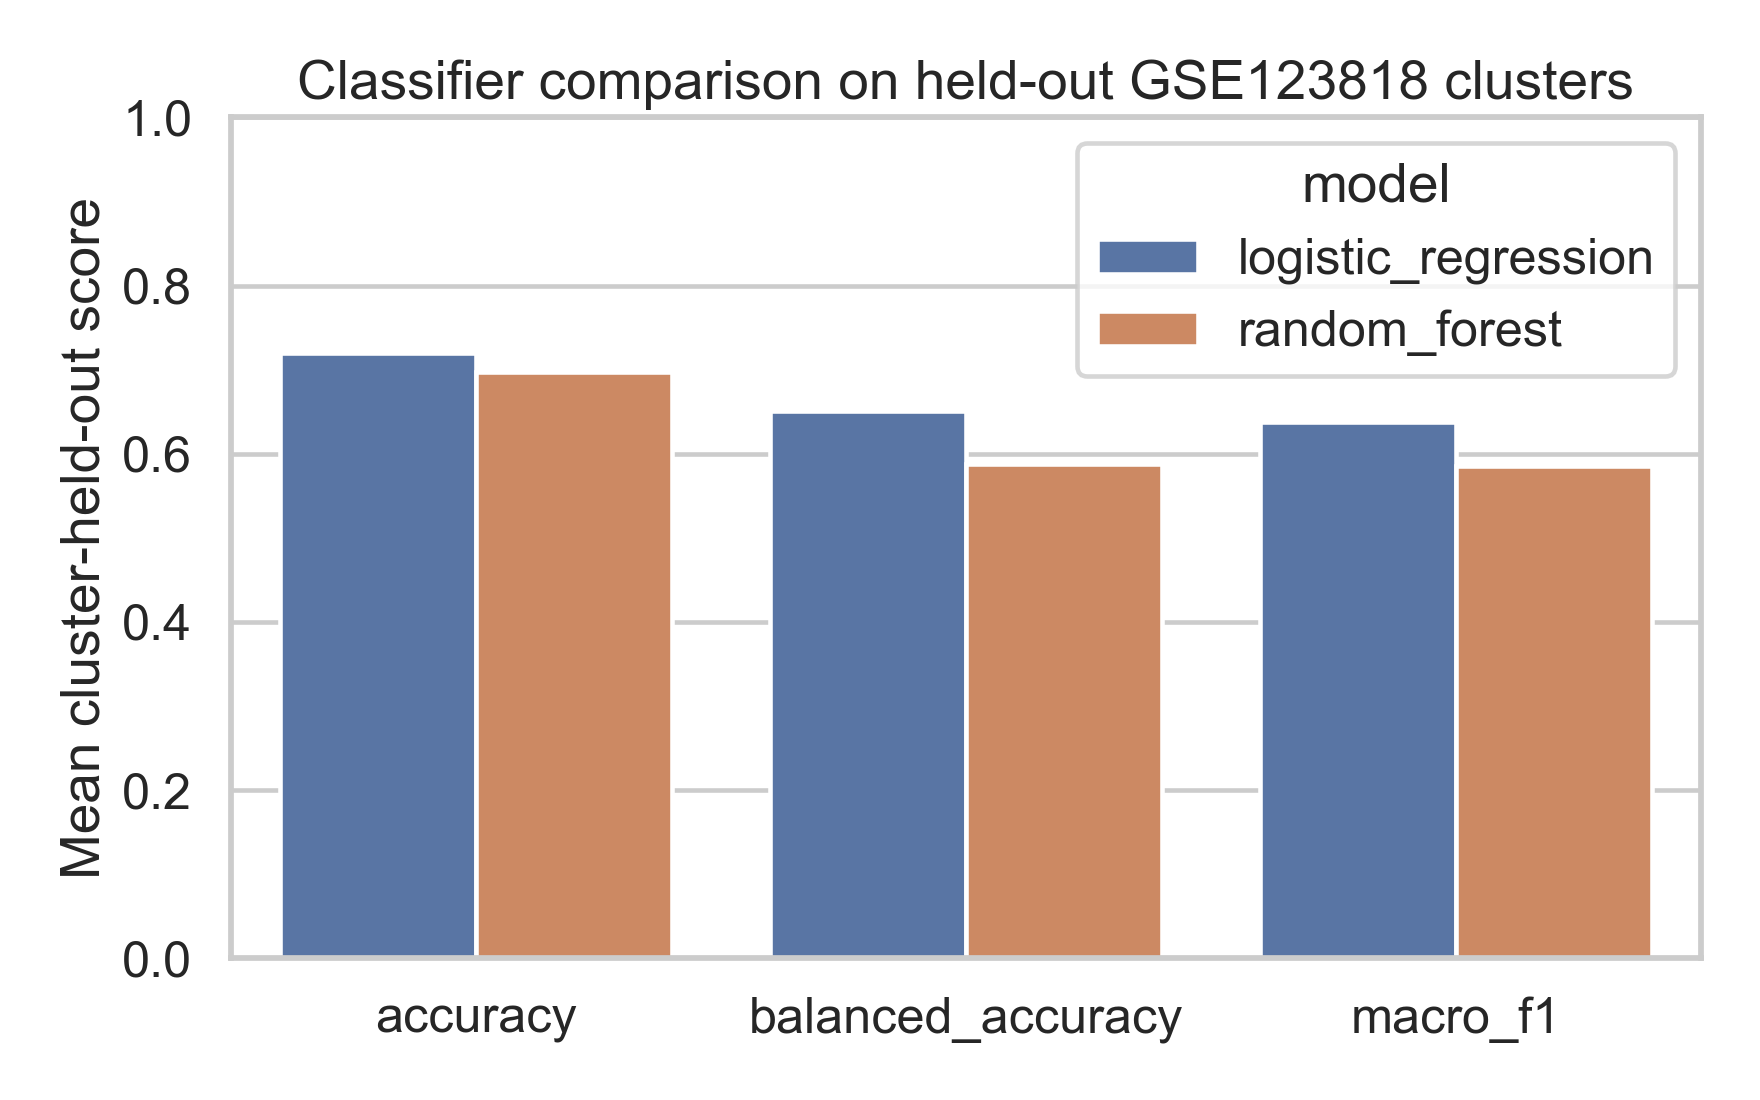

In [2]:
display(model_summary.style.format({
    "accuracy": "{:.3f}",
    "balanced_accuracy": "{:.3f}",
    "macro_f1": "{:.3f}",
    "log_loss": "{:.3f}",
    "mean_confidence": "{:.3f}",
    "expected_calibration_error": "{:.3f}",
}))
display(Image(filename=str(FIGURE_DIR / "classifier_metric_comparison.png"), width=850))

In [3]:
logistic = model_summary.set_index("model").loc["logistic_regression"]
forest = model_summary.set_index("model").loc["random_forest"]
display(Markdown(f"""
### Interpretation

- Logistic regression has higher balanced accuracy (**{logistic['balanced_accuracy']:.3f}**) and macro F1 (**{logistic['macro_f1']:.3f}**) than random forest (**{forest['balanced_accuracy']:.3f}** and **{forest['macro_f1']:.3f}**).
- Logistic regression nevertheless has much worse log loss (**{logistic['log_loss']:.3f}**) and calibration error (**{logistic['expected_calibration_error']:.3f}**).
- After temperature scaling, calibration error falls to **{logistic['calibrated_expected_calibration_error']:.3f}** for logistic regression and **{forest['calibrated_expected_calibration_error']:.3f}** for random forest.
- Logistic regression is better at choosing the pseudo-label, while random forest contributes complementary uncertainty information. Requiring agreement uses both behaviors.
"""))


### Interpretation

- Logistic regression has higher balanced accuracy (**0.650**) and macro F1 (**0.637**) than random forest (**0.588** and **0.586**).
- Logistic regression nevertheless has much worse log loss (**2.061**) and calibration error (**0.233**).
- After temperature scaling, calibration error falls to **0.055** for logistic regression and **0.028** for random forest.
- Logistic regression is better at choosing the pseudo-label, while random forest contributes complementary uncertainty information. Requiring agreement uses both behaviors.


## 3. Confusion matrices

Each row sums to one and represents recall for one held-out pseudo-label. Diagonal values are correct recoveries; off-diagonal values show which programs are confused.

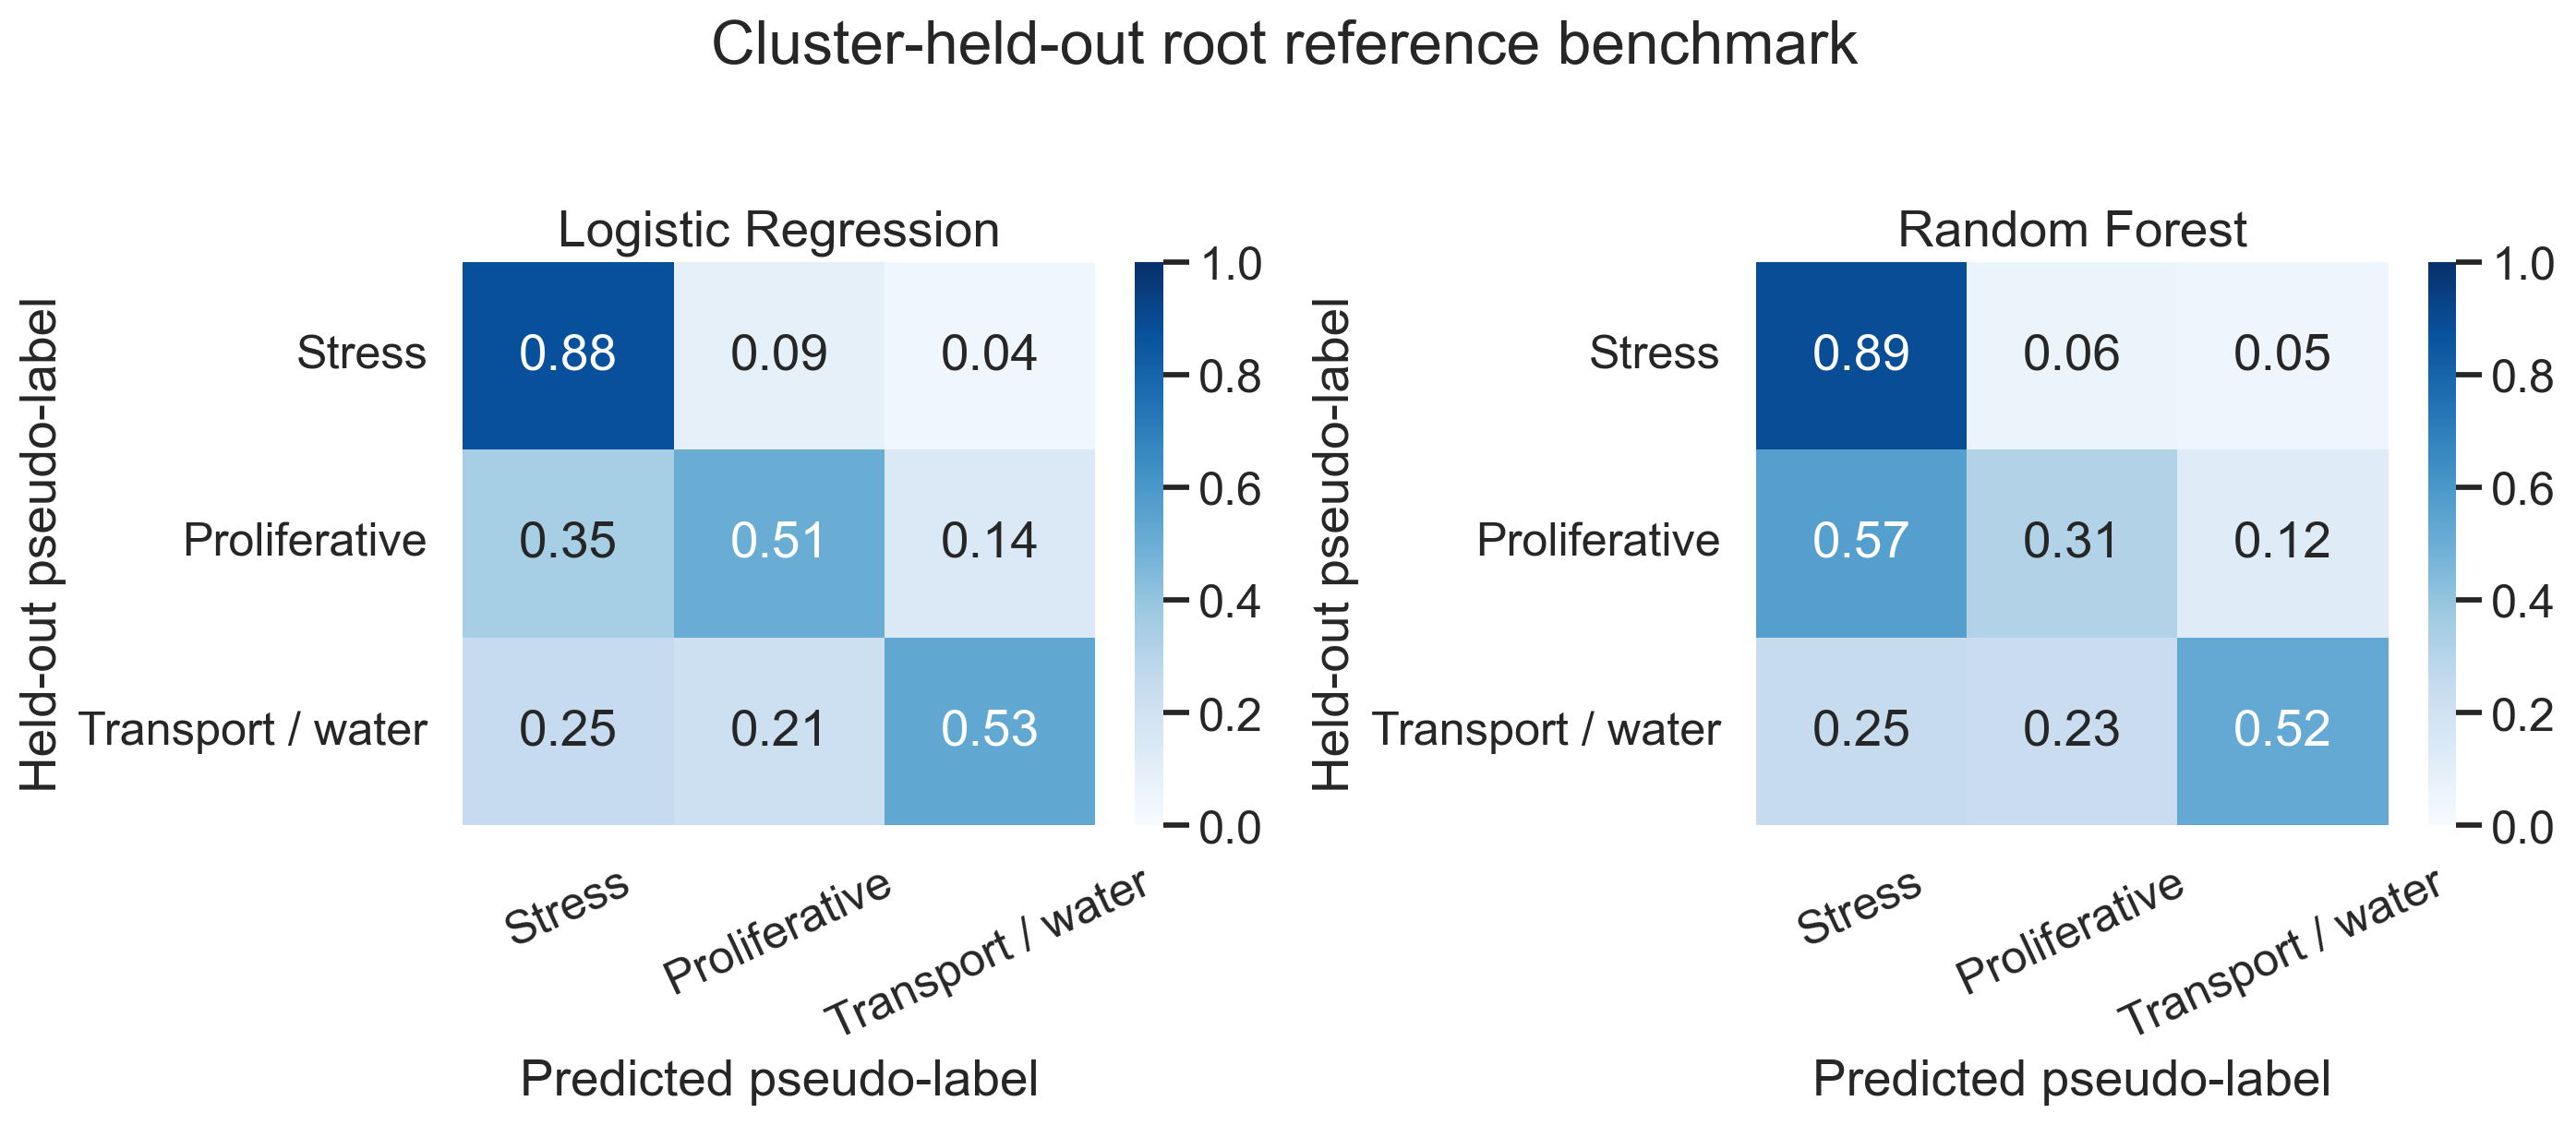

In [4]:
display(Image(filename=str(FIGURE_DIR / "cluster_heldout_confusion_matrices.png"), width=1200))

### Interpretation

Both models recover the stress pseudo-label well (0.88–0.89 recall). Transport/water cells are recovered only about half the time. The proliferative program is the least robust: logistic regression recalls 0.51, while random forest recalls 0.31 and misclassifies 0.57 as stress.

This asymmetry suggests that the stress program is broad and comparatively easy to detect, while proliferative and transport states overlap with it or lack sufficiently distinctive training examples. A future Wolffia stress prediction should therefore be checked carefully for classifier attraction toward the dominant program.

## 4. Confidence calibration

A perfectly calibrated model lies on the dashed diagonal: among predictions made with 80% confidence, about 80% should be correct. Points below the line indicate overconfidence. The left panel shows raw probabilities; the right shows cluster-held-out temperature scaling.

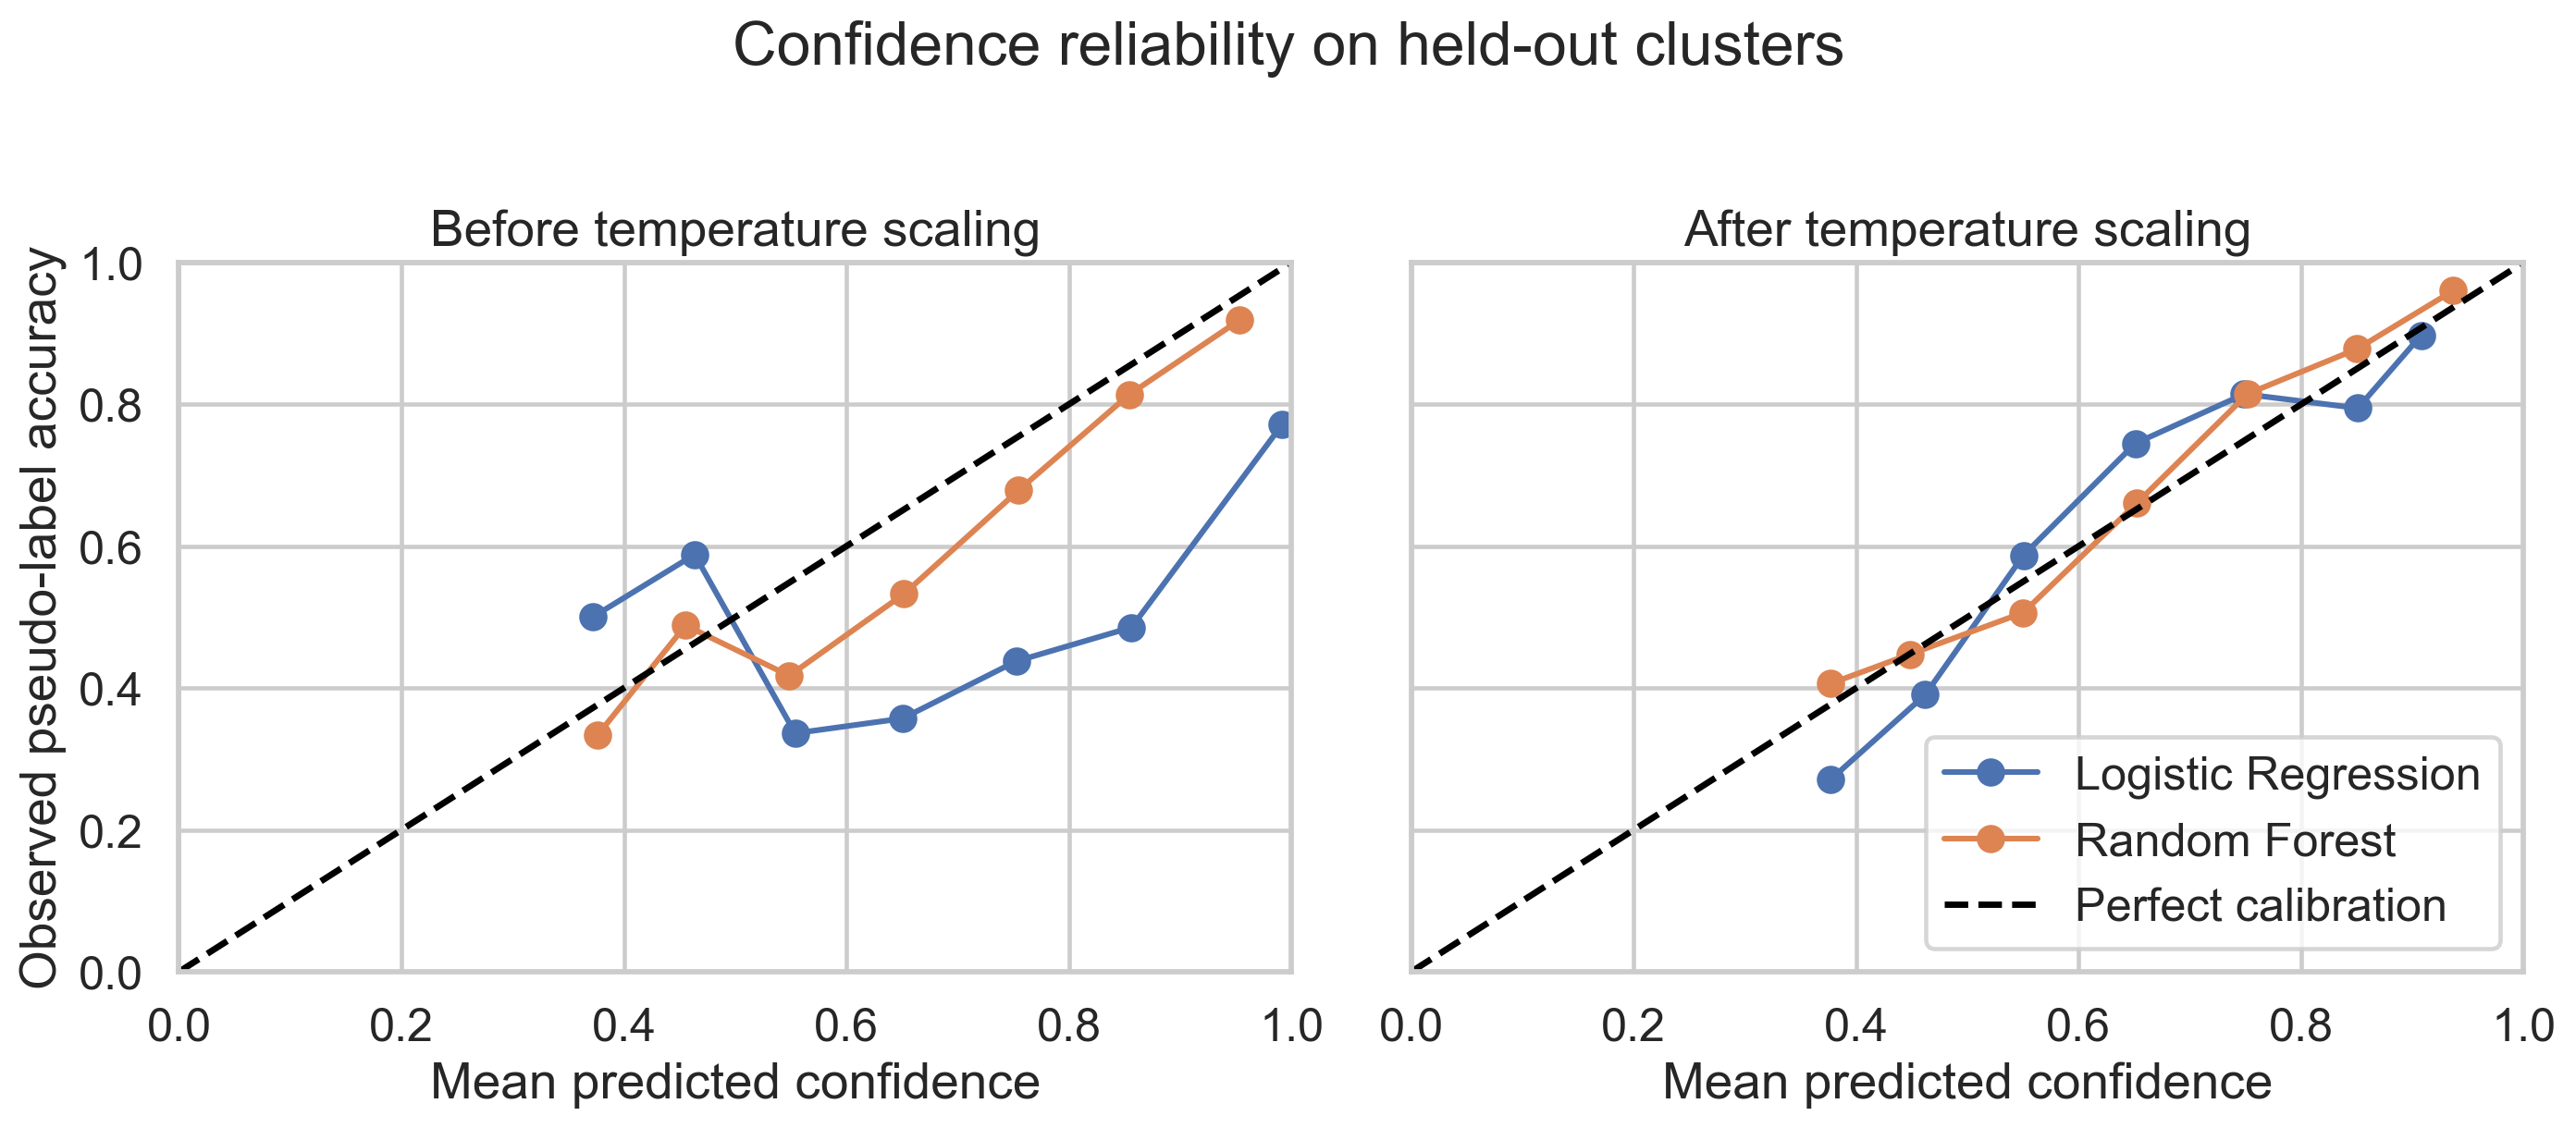

In [5]:
display(Image(filename=str(FIGURE_DIR / "classifier_confidence_reliability.png"), width=750))

### Interpretation

Before calibration, logistic regression is strongly overconfident at the high-confidence end: average confidence is approximately 0.95 despite accuracy near 0.72. Temperature scaling reduces its calibration error from 0.233 to 0.055 and random-forest error from 0.062 to 0.028.

Even calibrated confidence is not a biological certainty score. Consensus acceptance requires both models, marker evidence, and explicit thresholds.

## 5. Conservative GSE121619 consensus

A GSE121619 cell is accepted only when both classifiers agree, both meet the 0.60 confidence threshold, the prediction matches the strongest marker module, and the marker-score margin is at least 0.05.

,label,n_cells,proportion
0,ambiguous,1265,60.7%
1,transport_interface_or_water_balance,705,33.8%
2,proliferative_or_meristematic,60,2.9%
3,abiotic_stress_response,55,2.6%


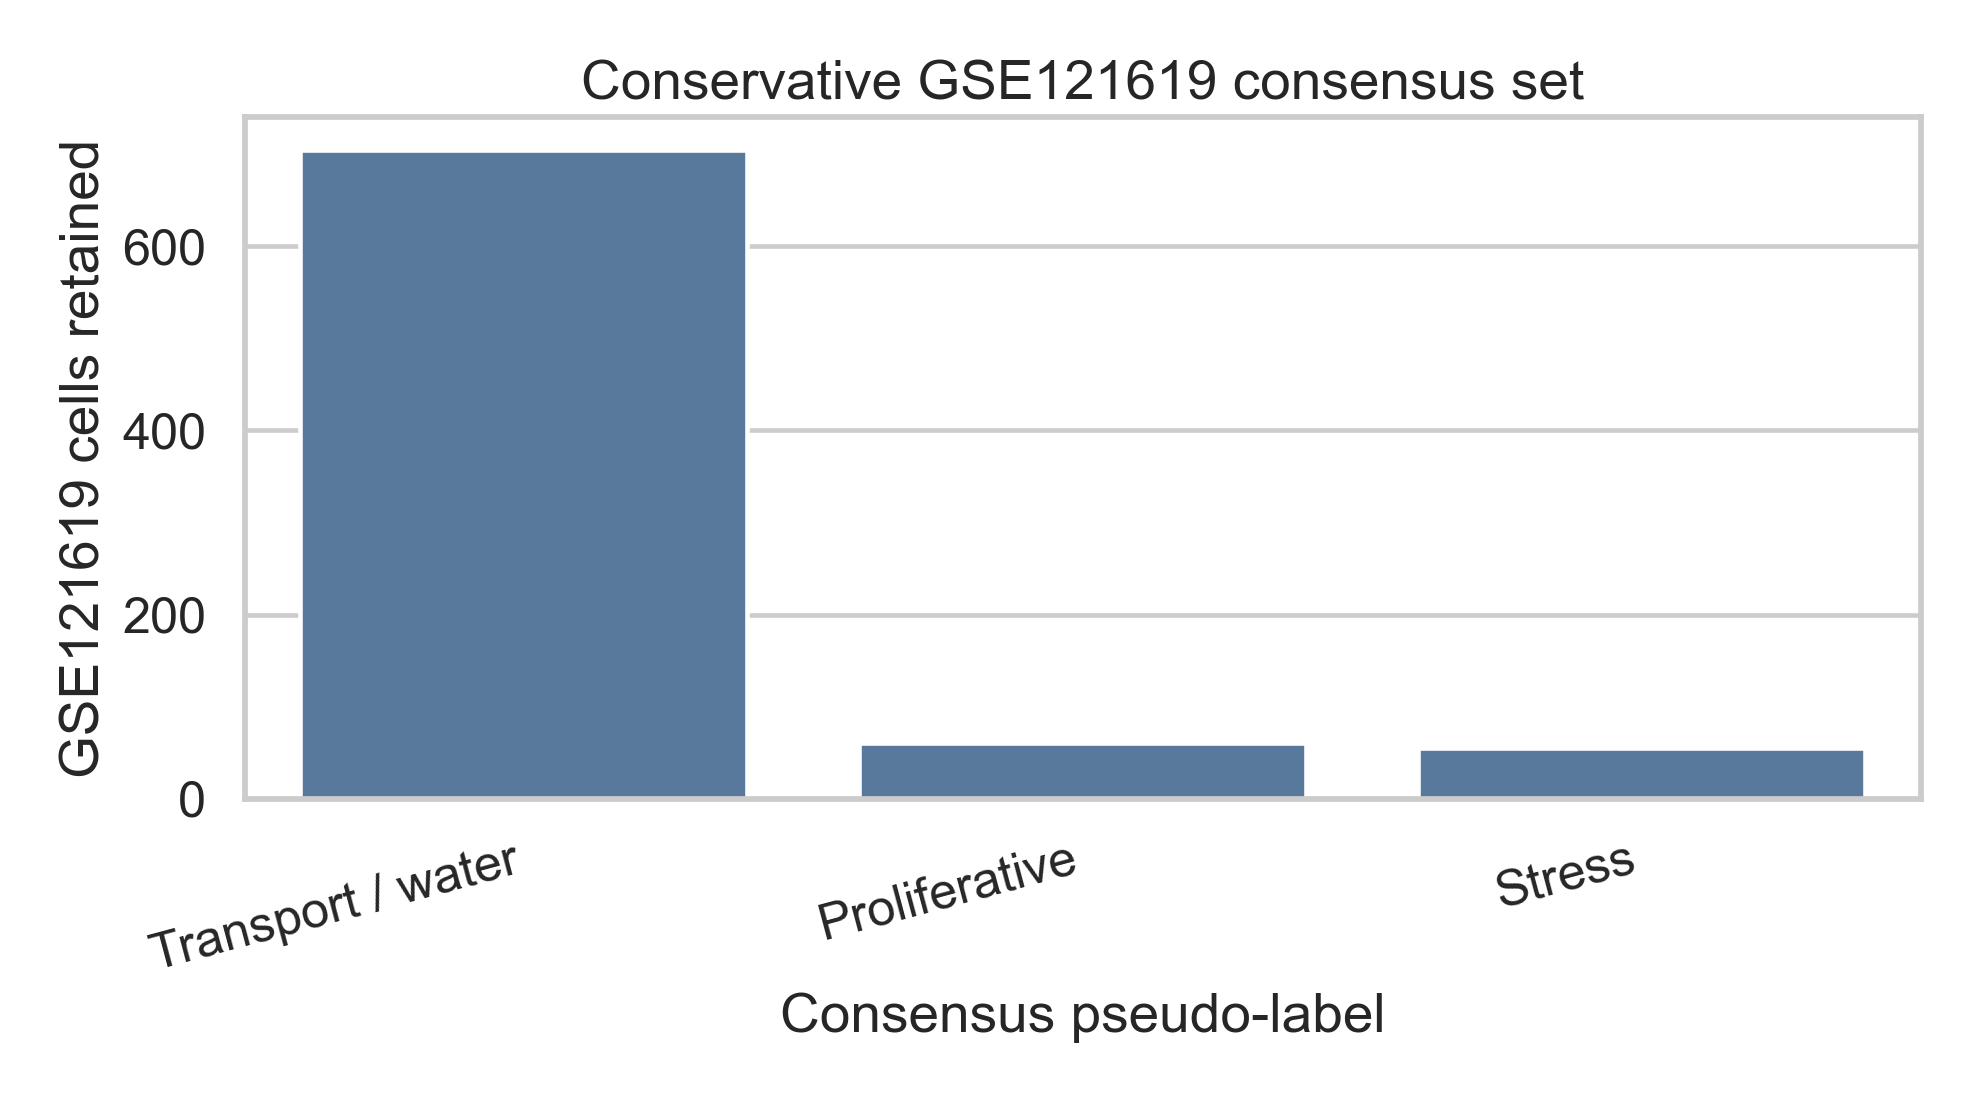

In [6]:
accepted = predictions[predictions["consensus_accepted"]]
acceptance_rate = len(accepted) / len(predictions)
consensus_counts = predictions["consensus_label"].value_counts().rename_axis("label").reset_index(name="n_cells")
consensus_counts["proportion"] = consensus_counts["n_cells"] / len(predictions)
display(consensus_counts.style.format({"proportion": "{:.1%}"}))
display(Image(filename=str(FIGURE_DIR / "gse121619_consensus_counts.png"), width=950))

In [7]:
rejection_checks = pd.DataFrame({
    "criterion_not_met": [
        "Models disagree",
        "Model consensus disagrees with marker winner",
        "At least one model confidence is below 0.60",
        "Marker-score margin is below 0.05",
    ],
    "n_cells": [
        (~predictions["model_agreement"]).sum(),
        (~predictions["marker_agreement"]).sum(),
        (predictions["minimum_model_confidence"] < 0.60).sum(),
        (predictions["marker_margin"] < 0.05).sum(),
    ],
})
display(rejection_checks)
display(Markdown(f"""
### Interpretation

The filter retains **{len(accepted):,} of {len(predictions):,} cells ({acceptance_rate:.1%})**. Retained labels are dominated by transport/water (**{(accepted['consensus_label'] == 'transport_interface_or_water_balance').sum():,} cells**), followed by stress (**{(accepted['consensus_label'] == 'abiotic_stress_response').sum():,}**) and proliferative (**{(accepted['consensus_label'] == 'proliferative_or_meristematic').sum():,}**).

The largest rejection source is disagreement between model consensus and the marker winner. Rejection criteria overlap, so their counts do not sum to the number of rejected cells. Keeping **{1-acceptance_rate:.1%}** ambiguous is intentional: uncertainty is more scientifically useful than forcing every cell into a familiar program.
"""))

,criterion_not_met,n_cells
0,Models disagree,281
1,Model consensus disagrees with marker winner,755
2,At least one model confidence is below 0.60,1072
3,Marker-score margin is below 0.05,125



### Interpretation

The filter retains **820 of 2,085 cells (39.3%)**. Retained labels are dominated by transport/water (**705 cells**), followed by stress (**55**) and proliferative (**60**).

The largest rejection source is disagreement between model consensus and the marker winner. Rejection criteria overlap, so their counts do not sum to the number of rejected cells. Keeping **60.7%** ambiguous is intentional: uncertainty is more scientifically useful than forcing every cell into a familiar program.


## 6. Conclusions

### Supported

- A root-derived reference transfers more evenly than the earlier callus-derived reference.
- Logistic regression and random forest provide partially complementary evidence.
- Three coarse programs can be recovered, but their robustness is unequal.
- A conservative consensus set can incorporate information from GSE121619 without treating all predictions as truth.

### Not yet supported

- The benchmark does not establish expert-level cell-type accuracy.
- The three broad programs are not a complete Arabidopsis root ontology.
- A high model confidence is not sufficient evidence of biological identity.
- These results do not yet demonstrate preserved or compressed programs in Wolffia.

### Next computational checkpoint

Before applying the models to Wolffia, add ortholog mapping and a formal rejection rule based on model agreement, calibrated confidence, marker coverage, and stability across reference choices. The final Wolffia output should preserve an `ambiguous` category rather than force every cell into one of the three programs.